C:\Users\asojitra\AppData\Local\Temp\ipykernel_19640\2412751230.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma')


Using device: cuda
Generating dataset...


Generating NACA airfoils: 100%|██████████| 1250/1250 [00:06<00:00, 195.91it/s]


Dataset generation complete.
Input masks shape : (1250, 256, 256)
Target SDFs shape : (1250, 256, 256)


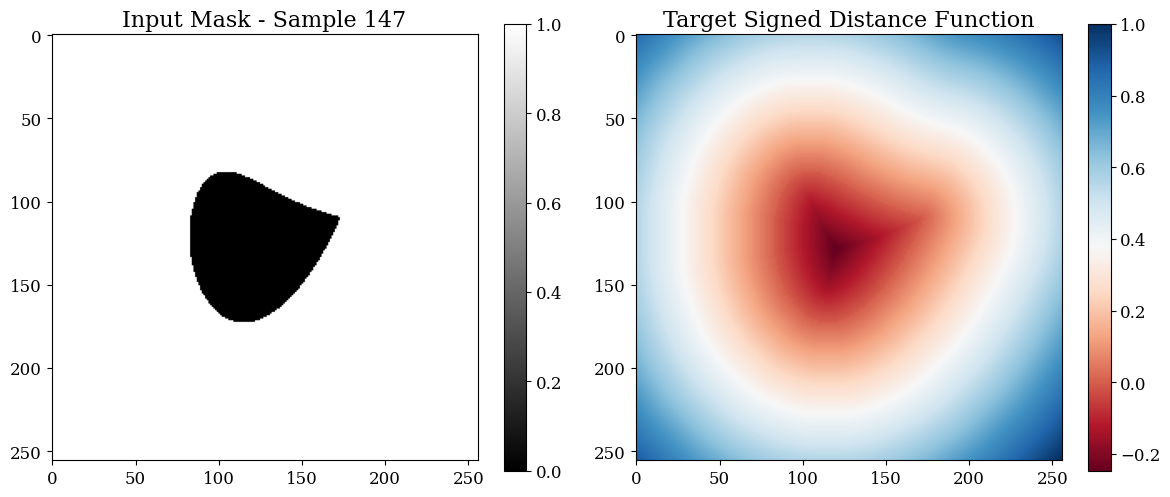

Train set: X=(1000, 256, 256), y=(1000, 256, 256)
Test  set: X=(250, 256, 256), y=(250, 256, 256)

Training DeepONet...

[DeepONet] Epoch [001/325] | Train Loss: 6.82867856e-02 | Test Loss: 4.90594870e-02
[DeepONet] Epoch [051/325] | Train Loss: 3.33953100e-04 | Test Loss: 3.27583378e-04
[DeepONet] Epoch [101/325] | Train Loss: 2.09195758e-04 | Test Loss: 2.11826355e-04
[DeepONet] Epoch [151/325] | Train Loss: 1.15149342e-04 | Test Loss: 1.27849669e-04
[DeepONet] Epoch [201/325] | Train Loss: 1.07162823e-04 | Test Loss: 8.01001018e-05
[DeepONet] Epoch [251/325] | Train Loss: 7.46605407e-05 | Test Loss: 9.45237555e-05
[DeepONet] Epoch [301/325] | Train Loss: 8.00342159e-05 | Test Loss: 6.81550708e-05
[DeepONet] Epoch [325/325] | Train Loss: 5.64239558e-05 | Test Loss: 6.27117921e-05

Training FEDONet...

[FEDONet]  Epoch [001/325] | Train Loss: 7.56791137e-02 | Test Loss: 4.89802396e-02
[FEDONet]  Epoch [051/325] | Train Loss: 7.91177228e-05 | Test Loss: 7.86991707e-05
[FEDONet]  Epoch 

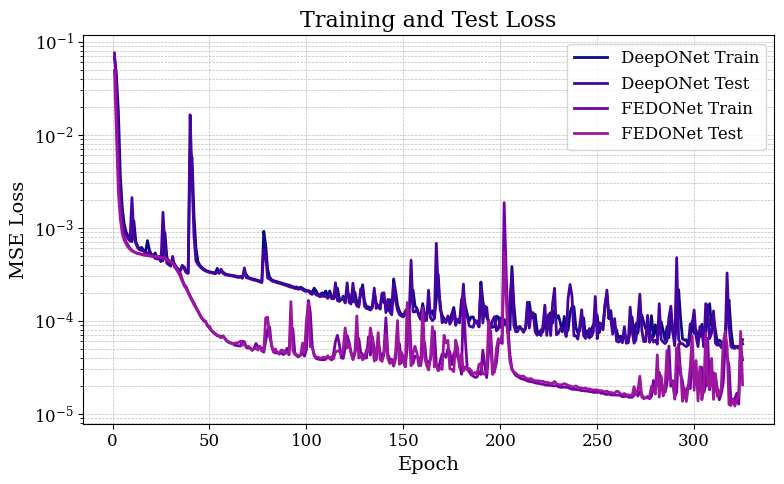


Clean test performance:

Model       Mean RelL2    Std RelL2    Mean MSE    Mean MAE    Mean SSIM
--------  ------------  -----------  ----------  ----------  -----------
DeepONet      0.015228     0.005703    0.000051    0.004754     0.990237
FEDONet       0.007477     0.002830    0.000012    0.002460     0.996872


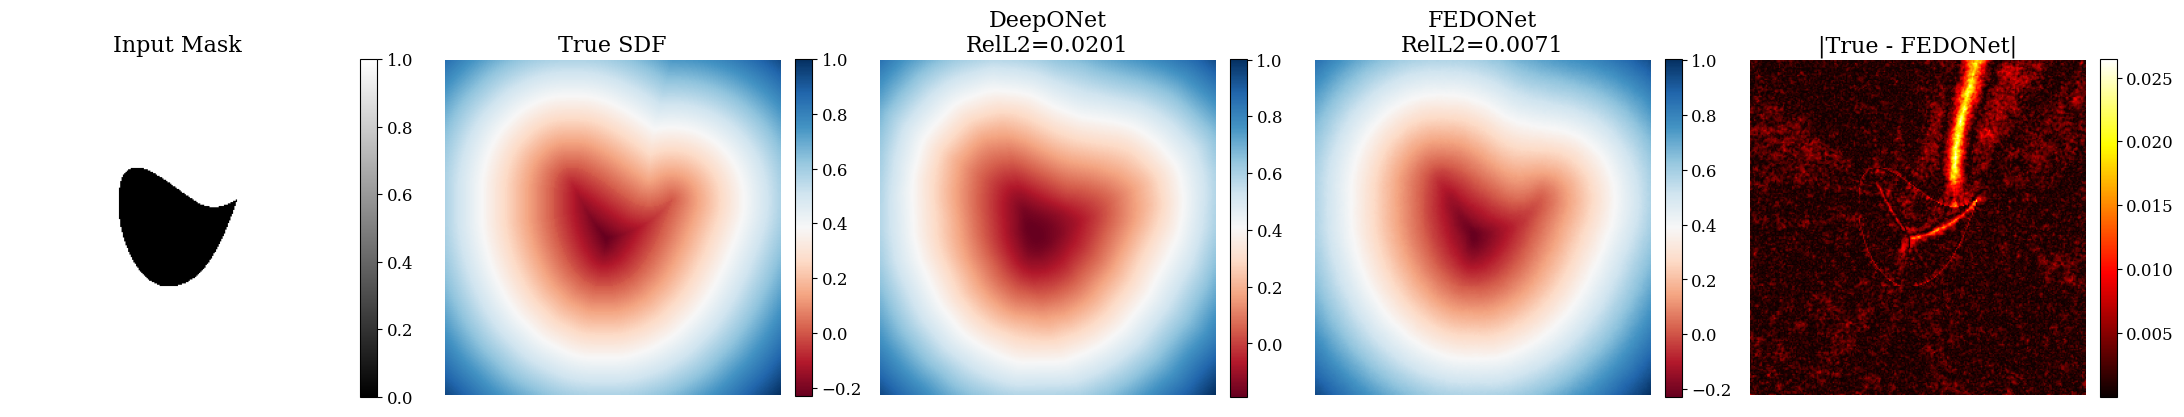


Running Gaussian-clipped noise robustness test...

Noise robustness results:

  Noise Level    DeepONet Mean RelL2    DeepONet Std    FEDONet Mean RelL2    FEDONet Std
-------------  ---------------------  --------------  --------------------  -------------
     0.000000               0.015228        0.005703              0.007477       0.002830
     0.010000               0.015215        0.005653              0.007774       0.002731
     0.020000               0.016265        0.005375              0.008935       0.002521
     0.050000               0.023785        0.004121              0.015147       0.001972
     0.100000               0.049100        0.003037              0.027727       0.002121
     0.150000               0.065964        0.003685              0.040867       0.002555
     0.200000               0.123611        0.006971              0.051833       0.003783
     0.300000               0.255911        0.011882              0.071224       0.007018


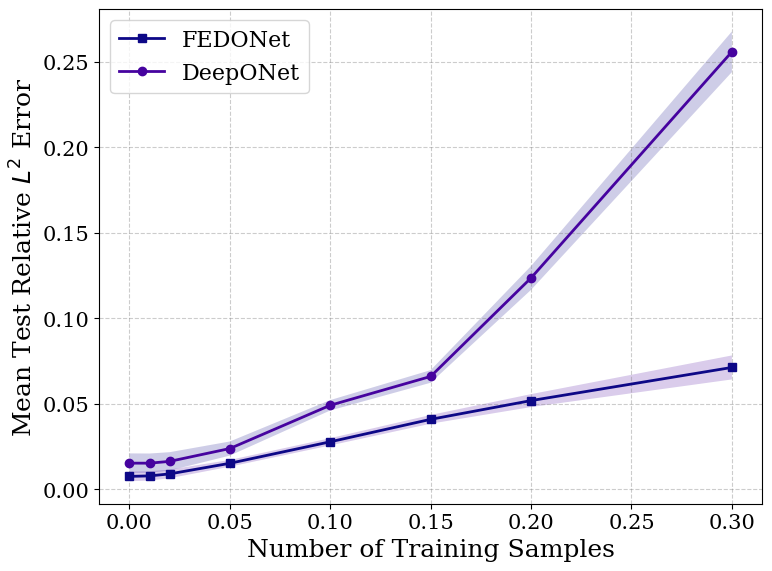

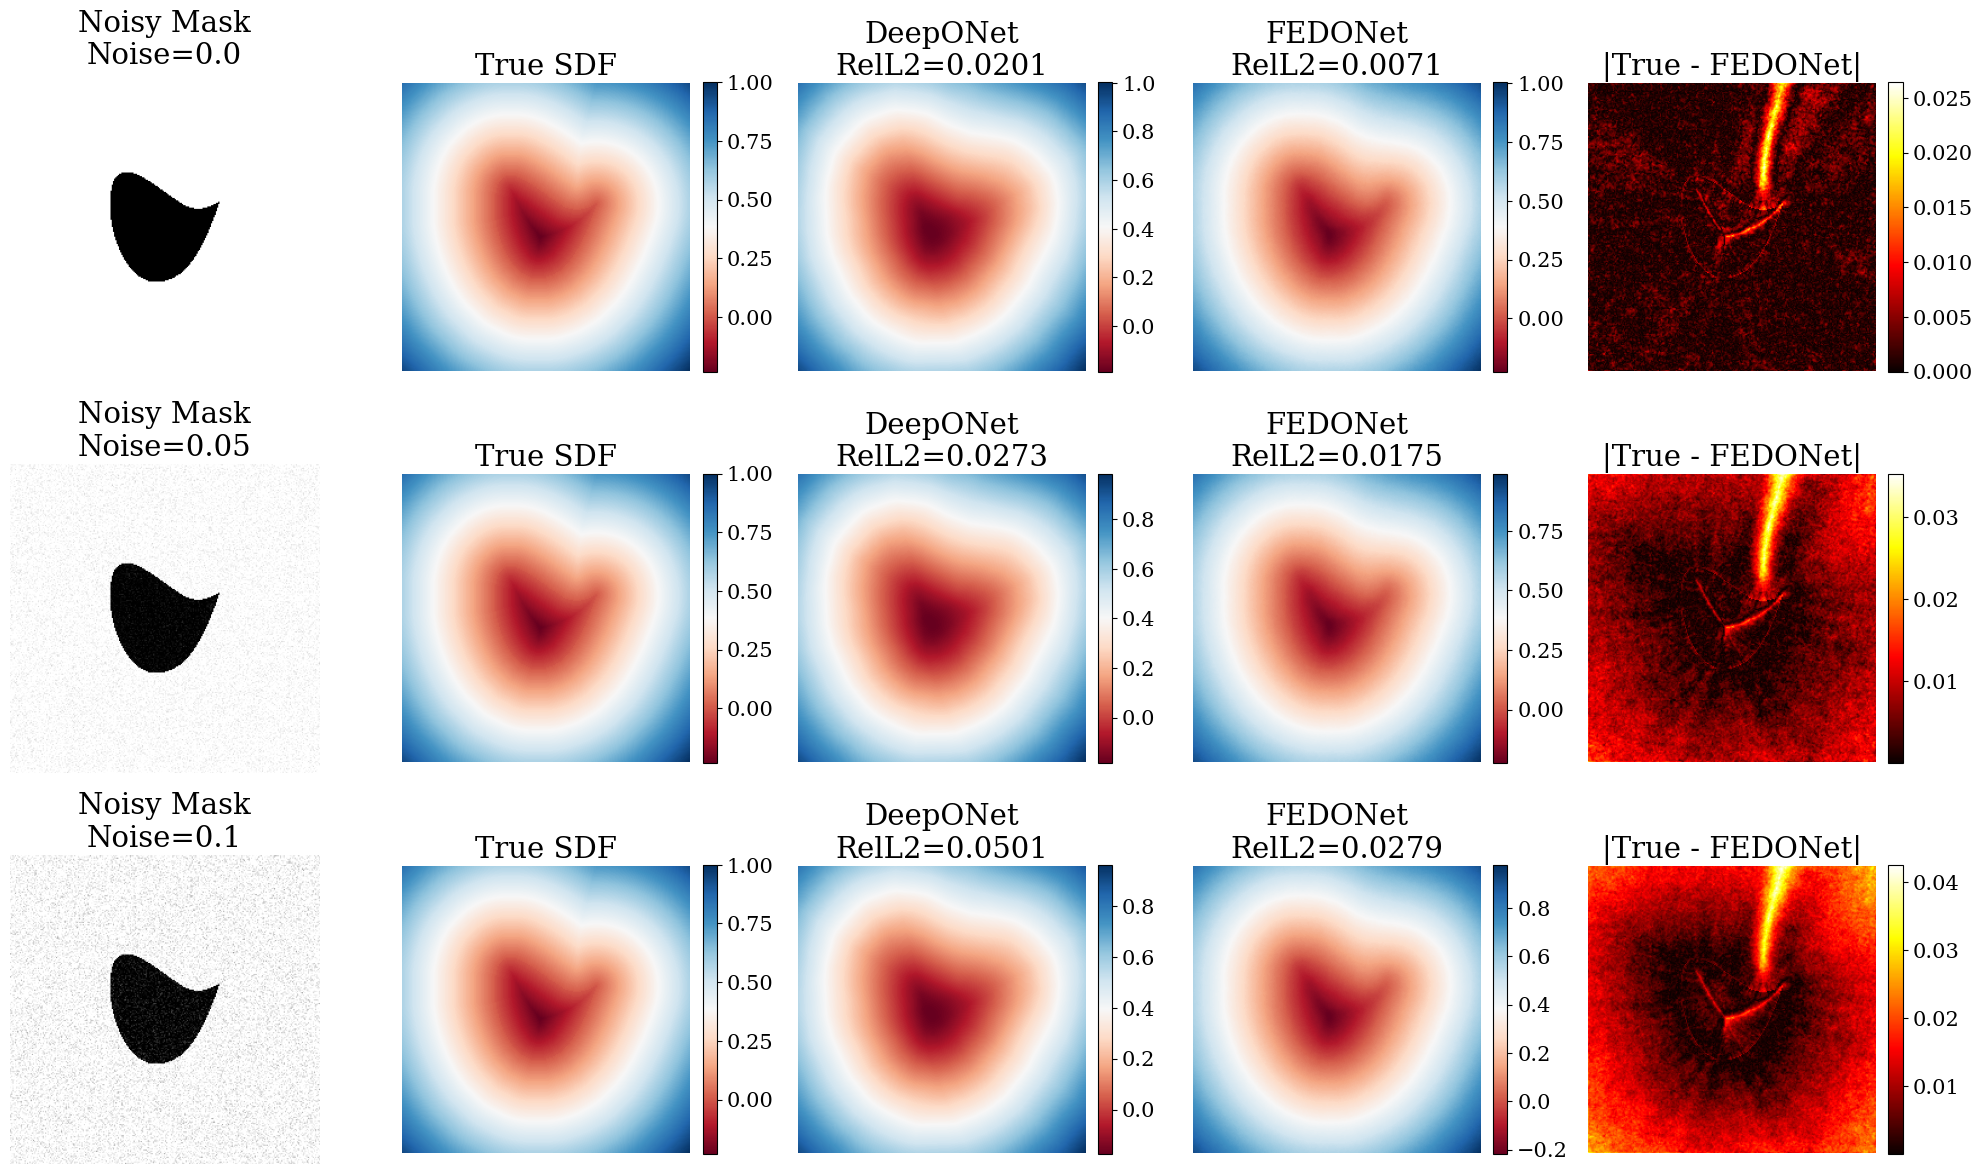

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tabulate import tabulate
from tqdm import tqdm

from scipy.ndimage import distance_transform_edt
from skimage.draw import polygon
from skimage.metrics import structural_similarity as ssim

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 2. USER SETTINGS
# ============================================================
num_airfoils = 1250
grid_size = 256
airfoil_size = 92

test_size = 0.2
batch_size = 64
num_epochs = 325
learning_rate = 1e-4

latent_dim = 100
fourier_mapping_size = 512
fourier_scale = 10.0

save_dataset = False
save_models = False

noise_levels = [0.00, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]

# ============================================================
# 3. PLOTTING STYLE
# ============================================================
def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300

    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12

    mpl.rcParams['lines.linewidth'] = 2
    mpl.rcParams['lines.markersize'] = 6

    mpl.rcParams['contour.negative_linestyle'] = 'solid'

    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5

    mpl.rcParams['image.cmap'] = 'plasma'

    plasma_cmap = mpl.cm.get_cmap('plasma')
    colors = [plasma_cmap(i) for i in np.linspace(0, 1, 10)]
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

set_plot_params()

# ============================================================
# 4. METRICS
# ============================================================
def relative_l2_error_np(true, pred, eps=1e-12):
    num = np.linalg.norm((true - pred).ravel(), 2)
    den = np.linalg.norm(true.ravel(), 2) + eps
    return num / den

def compute_mse_np(true, pred):
    return np.mean((true - pred) ** 2)

def compute_mae_np(true, pred):
    return np.mean(np.abs(true - pred))

def compute_ssim_np(true, pred):
    data_range = true.max() - true.min()
    if data_range < 1e-12:
        data_range = 1.0
    return ssim(true, pred, data_range=data_range)

def batch_relative_l2_error_torch(true, pred, eps=1e-12):
    # true, pred: [B, 1, H, W]
    true_np = true.detach().cpu().numpy()
    pred_np = pred.detach().cpu().numpy()

    B = true_np.shape[0]
    rel_errors = np.zeros(B, dtype=np.float64)

    for i in range(B):
        rel_errors[i] = relative_l2_error_np(true_np[i, 0], pred_np[i, 0], eps=eps)

    return rel_errors

# ============================================================
# 5. AIRFOIL + SDF DATASET GENERATION
# ============================================================
def naca4_series(m, p, t, num_points=100):
    x = np.linspace(0, 1, num_points)

    if p == 0:
        yc = np.zeros_like(x)
        dyc_dx = np.zeros_like(x)
    else:
        yc = np.where(
            x < p,
            (m / p**2) * (2 * p * x - x**2),
            (m / (1 - p)**2) * ((1 - 2 * p) + 2 * p * x - x**2)
        )
        dyc_dx = np.where(
            x < p,
            (2 * m / p**2) * (p - x),
            (2 * m / (1 - p)**2) * (p - x)
        )

    theta = np.arctan(dyc_dx)

    yt = 5 * t * (
        0.2969 * np.sqrt(np.clip(x, 1e-12, None))
        - 0.1260 * x
        - 0.3516 * x**2
        + 0.2843 * x**3
        - 0.1036 * x**4
    )

    xu = x - yt * np.sin(theta)
    xl = x + yt * np.sin(theta)
    yu = yc + yt * np.cos(theta)
    yl = yc - yt * np.cos(theta)

    X = np.concatenate((xu, xl[::-1]))
    Y = np.concatenate((yu, yl[::-1]))

    return X, Y

def airfoil_to_large_grid(x, y, grid_size=256, airfoil_size=128):
    x_scaled = (x - np.min(x)) / (np.max(x) - np.min(x)) * (airfoil_size - 1)
    y_scaled = (y - np.min(y)) / (np.max(y) - np.min(y)) * (airfoil_size - 1)

    x_shifted = x_scaled + (grid_size - airfoil_size) // 2
    y_shifted = y_scaled + (grid_size - airfoil_size) // 2

    x_shifted = np.clip(x_shifted, 0, grid_size - 1)
    y_shifted = np.clip(y_shifted, 0, grid_size - 1)

    # 1 = outside airfoil, 0 = inside airfoil
    img = np.ones((grid_size, grid_size), dtype=np.uint8)
    rr, cc = polygon(y_shifted, x_shifted, img.shape)
    img[rr, cc] = 0

    return img

def compute_signed_distance(airfoil_mask):
    # mask convention:
    #   1 outside airfoil
    #   0 inside airfoil

    sdf_outside = distance_transform_edt(airfoil_mask)
    sdf_inside = distance_transform_edt(1 - airfoil_mask)
    sdf = sdf_outside - sdf_inside

    max_abs = np.max(np.abs(sdf))
    if max_abs > 0:
        sdf = sdf / max_abs

    return sdf.astype(np.float32)

def generate_airfoil_dataset(num_airfoils, grid_size, airfoil_size):
    masks = np.zeros((num_airfoils, grid_size, grid_size), dtype=np.float32)
    sdfs = np.zeros((num_airfoils, grid_size, grid_size), dtype=np.float32)

    for i in tqdm(range(num_airfoils), desc="Generating NACA airfoils"):
        m = random.uniform(0.01, 0.09)
        p = random.uniform(0.1, 0.7)
        t = random.uniform(0.1, 0.4)

        x, y = naca4_series(m, p, t)
        mask = airfoil_to_large_grid(x, y, grid_size=grid_size, airfoil_size=airfoil_size)
        sdf = compute_signed_distance(mask)

        masks[i] = mask.astype(np.float32)
        sdfs[i] = sdf

    return masks, sdfs

print("Generating dataset...")
input_masks, target_sdfs = generate_airfoil_dataset(
    num_airfoils=num_airfoils,
    grid_size=grid_size,
    airfoil_size=airfoil_size
)

if save_dataset:
    np.save("airfoil_masks.npy", input_masks)
    np.save("airfoil_sdfs.npy", target_sdfs)

print("Dataset generation complete.")
print(f"Input masks shape : {input_masks.shape}")
print(f"Target SDFs shape : {target_sdfs.shape}")

# ============================================================
# 6. VISUALIZE ONE SAMPLE
# ============================================================
sample_idx = random.randint(0, num_airfoils - 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title(f"Input Mask - Sample {sample_idx}")
plt.imshow(input_masks[sample_idx], cmap='gray')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Target Signed Distance Function")
plt.imshow(target_sdfs[sample_idx], cmap='RdBu')
plt.colorbar()

plt.tight_layout()
plt.show()

# ============================================================
# 7. TRAIN/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    input_masks,
    target_sdfs,
    test_size=test_size,
    random_state=42
)

print(f"Train set: X={X_train.shape}, y={y_train.shape}")
print(f"Test  set: X={X_test.shape}, y={y_test.shape}")

# ============================================================
# 8. DATASET CLASS
# ============================================================
class EikonalAirfoilDataset(Dataset):
    def __init__(self, masks, sdfs):
        self.masks = torch.tensor(masks, dtype=torch.float32).unsqueeze(1)  # [N,1,H,W]
        self.sdfs = torch.tensor(sdfs, dtype=torch.float32).unsqueeze(1)    # [N,1,H,W]

        self.grid_size = self.masks.shape[-1]
        grid = np.linspace(0.0, 1.0, self.grid_size, dtype=np.float32)
        X, Y = np.meshgrid(grid, grid, indexing='xy')
        coords = np.stack([X, Y], axis=-1)  # [H,W,2]
        self.coords = torch.tensor(coords, dtype=torch.float32)

    def __len__(self):
        return self.masks.shape[0]

    def __getitem__(self, idx):
        return self.masks[idx], self.sdfs[idx]

train_dataset = EikonalAirfoilDataset(X_train, y_train)
test_dataset = EikonalAirfoilDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

coords = train_dataset.coords.to(device)

# ============================================================
# 9. MODEL DEFINITIONS
# ============================================================
class BranchNet(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),   # 256 -> 128
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2),  # 128 -> 64
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),  # 64 -> 32
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        return self.conv_layers(x)

class TrunkNet(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.fc_layers = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

    def forward(self, coords):
        return self.fc_layers(coords)

class DeepONet(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.branch_net = BranchNet(latent_dim=latent_dim)
        self.trunk_net = TrunkNet(latent_dim=latent_dim)

    def forward(self, masks, coords):
        # masks : [B,1,H,W]
        # coords: [H,W,2]
        batch_size = masks.size(0)
        H = coords.size(0)
        W = coords.size(1)

        coords_flat = coords.view(-1, 2)               # [H*W,2]
        trunk_out = self.trunk_net(coords_flat)        # [H*W,latent_dim]
        branch_out = self.branch_net(masks)            # [B,latent_dim]

        outputs = torch.matmul(branch_out, trunk_out.T)  # [B,H*W]
        outputs = outputs.view(batch_size, 1, H, W)

        return outputs

class FourierEmbedding(nn.Module):
    def __init__(self, input_dim=2, mapping_size=512, scale=10.0):
        super().__init__()
        B = torch.randn(input_dim, mapping_size) * scale
        self.register_buffer("B", B)

    def forward(self, x):
        x_proj = 2.0 * np.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class BranchNetFEDO(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        return self.conv_layers(x)

class TrunkNetFEDO(nn.Module):
    def __init__(self, input_dim=2, latent_dim=100, mapping_size=512, scale=10.0):
        super().__init__()
        self.fourier_embed = FourierEmbedding(
            input_dim=input_dim,
            mapping_size=mapping_size,
            scale=scale
        )
        self.fc = nn.Sequential(
            nn.Linear(2 * mapping_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x):
        x = self.fourier_embed(x)
        return self.fc(x)

class FEDONet(nn.Module):
    def __init__(self, input_dim=2, latent_dim=100, mapping_size=512, scale=10.0):
        super().__init__()
        self.branch_net = BranchNetFEDO(latent_dim=latent_dim)
        self.trunk_net = TrunkNetFEDO(
            input_dim=input_dim,
            latent_dim=latent_dim,
            mapping_size=mapping_size,
            scale=scale
        )

    def forward(self, masks, coords):
        batch_size = masks.size(0)
        H = coords.size(0)
        W = coords.size(1)

        coords_flat = coords.view(-1, 2)
        trunk_out = self.trunk_net(coords_flat)
        branch_out = self.branch_net(masks)

        outputs = torch.matmul(branch_out, trunk_out.T)
        outputs = outputs.view(batch_size, 1, H, W)

        return outputs

# ============================================================
# 10. TRAIN / EVAL FUNCTIONS
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device, coords):
    model.train()
    running_loss = 0.0

    for masks, sdfs in loader:
        masks = masks.to(device)
        sdfs = sdfs.to(device)

        optimizer.zero_grad()
        pred = model(masks, coords)
        loss = criterion(pred, sdfs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * masks.size(0)

    return running_loss / len(loader.dataset)

def evaluate_loss(model, loader, criterion, device, coords):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for masks, sdfs in loader:
            masks = masks.to(device)
            sdfs = sdfs.to(device)

            pred = model(masks, coords)
            loss = criterion(pred, sdfs)
            running_loss += loss.item() * masks.size(0)

    return running_loss / len(loader.dataset)

def evaluate_full_metrics(model, loader, device, coords):
    model.eval()

    rel_l2_list = []
    mse_list = []
    mae_list = []
    ssim_list = []

    with torch.no_grad():
        for masks, sdfs in loader:
            masks = masks.to(device)
            sdfs = sdfs.to(device)

            preds = model(masks, coords)

            preds_np = preds.detach().cpu().numpy()
            sdfs_np = sdfs.detach().cpu().numpy()

            for i in range(preds_np.shape[0]):
                true_i = sdfs_np[i, 0]
                pred_i = preds_np[i, 0]

                rel_l2_list.append(relative_l2_error_np(true_i, pred_i))
                mse_list.append(compute_mse_np(true_i, pred_i))
                mae_list.append(compute_mae_np(true_i, pred_i))
                ssim_list.append(compute_ssim_np(true_i, pred_i))

    return {
        "rel_l2_mean": float(np.mean(rel_l2_list)),
        "rel_l2_std": float(np.std(rel_l2_list)),
        "mse_mean": float(np.mean(mse_list)),
        "mae_mean": float(np.mean(mae_list)),
        "ssim_mean": float(np.mean(ssim_list)),
    }

# ============================================================
# 11. TRAIN DEEPONET
# ============================================================
deeponet = DeepONet(latent_dim=latent_dim).to(device)
criterion = nn.MSELoss()
optimizer_deep = optim.Adam(deeponet.parameters(), lr=learning_rate)

train_losses_deep = []
test_losses_deep = []

print("\nTraining DeepONet...\n")
best_test_loss_deep = float("inf")
best_state_deep = None

for epoch in range(num_epochs):
    train_loss = train_one_epoch(deeponet, train_loader, optimizer_deep, criterion, device, coords)
    test_loss = evaluate_loss(deeponet, test_loader, criterion, device, coords)

    train_losses_deep.append(train_loss)
    test_losses_deep.append(test_loss)

    if test_loss < best_test_loss_deep:
        best_test_loss_deep = test_loss
        best_state_deep = {k: v.cpu().clone() for k, v in deeponet.state_dict().items()}

    if epoch % 50 == 0 or epoch == num_epochs - 1:
        print(
            f"[DeepONet] Epoch [{epoch+1:03d}/{num_epochs}] | "
            f"Train Loss: {train_loss:.8e} | Test Loss: {test_loss:.8e}"
        )

if best_state_deep is not None:
    deeponet.load_state_dict(best_state_deep)

if save_models:
    torch.save(deeponet.state_dict(), "deeponet_eikonal_airfoil.pth")

# ============================================================
# 12. TRAIN FEDONET
# ============================================================
fedonet = FEDONet(
    input_dim=2,
    latent_dim=latent_dim,
    mapping_size=fourier_mapping_size,
    scale=fourier_scale
).to(device)

optimizer_fedo = optim.Adam(fedonet.parameters(), lr=learning_rate)

train_losses_fedo = []
test_losses_fedo = []

print("\nTraining FEDONet...\n")
best_test_loss_fedo = float("inf")
best_state_fedo = None

for epoch in range(num_epochs):
    train_loss = train_one_epoch(fedonet, train_loader, optimizer_fedo, criterion, device, coords)
    test_loss = evaluate_loss(fedonet, test_loader, criterion, device, coords)

    train_losses_fedo.append(train_loss)
    test_losses_fedo.append(test_loss)

    if test_loss < best_test_loss_fedo:
        best_test_loss_fedo = test_loss
        best_state_fedo = {k: v.cpu().clone() for k, v in fedonet.state_dict().items()}

    if epoch % 50 == 0 or epoch == num_epochs - 1:
        print(
            f"[FEDONet]  Epoch [{epoch+1:03d}/{num_epochs}] | "
            f"Train Loss: {train_loss:.8e} | Test Loss: {test_loss:.8e}"
        )

if best_state_fedo is not None:
    fedonet.load_state_dict(best_state_fedo)

if save_models:
    torch.save(fedonet.state_dict(), "fedonet_eikonal_airfoil.pth")

# ============================================================
# 13. PLOT TRAINING CURVES
# ============================================================
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, num_epochs + 1), train_losses_deep, label="DeepONet Train")
plt.semilogy(range(1, num_epochs + 1), test_losses_deep, label="DeepONet Test")
plt.semilogy(range(1, num_epochs + 1), train_losses_fedo, label="FEDONet Train")
plt.semilogy(range(1, num_epochs + 1), test_losses_fedo, label="FEDONet Test")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Test Loss")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 14. CLEAN TEST PERFORMANCE
# ============================================================
deep_metrics = evaluate_full_metrics(deeponet, test_loader, device, coords)
fedo_metrics = evaluate_full_metrics(fedonet, test_loader, device, coords)

print("\nClean test performance:\n")
print(tabulate(
    [
        ["DeepONet", deep_metrics["rel_l2_mean"], deep_metrics["rel_l2_std"], deep_metrics["mse_mean"], deep_metrics["mae_mean"], deep_metrics["ssim_mean"]],
        ["FEDONet",  fedo_metrics["rel_l2_mean"], fedo_metrics["rel_l2_std"], fedo_metrics["mse_mean"], fedo_metrics["mae_mean"], fedo_metrics["ssim_mean"]],
    ],
    headers=["Model", "Mean RelL2", "Std RelL2", "Mean MSE", "Mean MAE", "Mean SSIM"],
    floatfmt=".6f"
))

# ============================================================
# 15. VISUALIZE CLEAN PREDICTIONS
# ============================================================
masks_batch, sdfs_batch = next(iter(test_loader))
masks_batch = masks_batch.to(device)
sdfs_batch = sdfs_batch.to(device)

deeponet.eval()
fedonet.eval()

with torch.no_grad():
    pred_deep = deeponet(masks_batch, coords)
    pred_fedo = fedonet(masks_batch, coords)

idx = 0

mask_np = masks_batch[idx, 0].detach().cpu().numpy()
true_np = sdfs_batch[idx, 0].detach().cpu().numpy()
deep_np = pred_deep[idx, 0].detach().cpu().numpy()
fedo_np = pred_fedo[idx, 0].detach().cpu().numpy()

err_deep_np = np.abs(true_np - deep_np)
err_fedo_np = np.abs(true_np - fedo_np)

rel_deep = relative_l2_error_np(true_np, deep_np)
rel_fedo = relative_l2_error_np(true_np, fedo_np)

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

ax = axes[0]
im = ax.imshow(mask_np, cmap="gray")
ax.set_title("Input Mask")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im = ax.imshow(true_np, cmap="RdBu")
ax.set_title("True SDF")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[2]
im = ax.imshow(deep_np, cmap="RdBu")
ax.set_title(f"DeepONet\nRelL2={rel_deep:.4f}")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[3]
im = ax.imshow(fedo_np, cmap="RdBu")
ax.set_title(f"FEDONet\nRelL2={rel_fedo:.4f}")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[4]
im = ax.imshow(err_fedo_np, cmap="hot")
ax.set_title("|True - FEDONet|")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ============================================================
# 16. GAUSSIAN-CLIPPED NOISE ROBUSTNESS TEST
# ============================================================
def add_gaussian_clipped_noise(mask_tensor, noise_level):
    noisy_mask = mask_tensor + noise_level * torch.randn_like(mask_tensor)
    noisy_mask = torch.clamp(noisy_mask, 0.0, 1.0)
    return noisy_mask

def evaluate_model_with_noise(model, loader, coords, device, noise_level):
    model.eval()
    all_rel_l2 = []

    with torch.no_grad():
        for masks, true_sdfs in loader:
            masks = masks.to(device)
            true_sdfs = true_sdfs.to(device)

            noisy_masks = add_gaussian_clipped_noise(masks, noise_level)
            pred_sdfs = model(noisy_masks, coords)

            rel_l2_batch = batch_relative_l2_error_torch(true_sdfs, pred_sdfs)
            all_rel_l2.append(rel_l2_batch)

    all_rel_l2 = np.concatenate(all_rel_l2, axis=0)

    return {
        "mean": float(np.mean(all_rel_l2)),
        "std": float(np.std(all_rel_l2)),
        "all": all_rel_l2,
    }

deeponet_mean_errors = []
deeponet_std_errors = []

fedonet_mean_errors = []
fedonet_std_errors = []

results_table = []

print("\nRunning Gaussian-clipped noise robustness test...\n")

for nl in noise_levels:
    deep_stats = evaluate_model_with_noise(deeponet, test_loader, coords, device, nl)
    fedo_stats = evaluate_model_with_noise(fedonet, test_loader, coords, device, nl)

    deeponet_mean_errors.append(deep_stats["mean"])
    deeponet_std_errors.append(deep_stats["std"])

    fedonet_mean_errors.append(fedo_stats["mean"])
    fedonet_std_errors.append(fedo_stats["std"])

    results_table.append([
        nl,
        deep_stats["mean"],
        deep_stats["std"],
        fedo_stats["mean"],
        fedo_stats["std"]
    ])

print("Noise robustness results:\n")
print(tabulate(
    results_table,
    headers=[
        "Noise Level",
        "DeepONet Mean RelL2",
        "DeepONet Std",
        "FEDONet Mean RelL2",
        "FEDONet Std"
    ],
    floatfmt=".6f"
))

# ============================================================
# 17. PLOT ROBUSTNESS CURVE
# ============================================================

def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})

plt.figure(figsize=(8, 6))

plt.plot(
    noise_levels,
    fedonet_mean_errors,
    marker='s',
    linewidth=2,
    label='FEDONet'
)

plt.plot(
    noise_levels,
    deeponet_mean_errors,
    marker='o',
    linewidth=2,
    label='DeepONet'
)


plt.fill_between(
    noise_levels,
    np.array(deeponet_mean_errors) - np.array(deeponet_std_errors),
    np.array(deeponet_mean_errors) + np.array(deeponet_std_errors),
    alpha=0.2
)

plt.fill_between(
    noise_levels,
    np.array(fedonet_mean_errors) - np.array(fedonet_std_errors),
    np.array(fedonet_mean_errors) + np.array(fedonet_std_errors),
    alpha=0.2
)

plt.xlabel('Number of Training Samples')
plt.ylabel('Mean Test Relative $L^2$ Error')
# plt.title('Test Rel-L2 vs Fraction of Training Data', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 18. OPTIONAL: VISUALIZE NOISY TEST SAMPLE
# ============================================================
mask_batch, sdf_batch = next(iter(test_loader))
mask_batch = mask_batch.to(device)
sdf_batch = sdf_batch.to(device)

sample_idx = 0
mask_clean = mask_batch[sample_idx:sample_idx+1]
sdf_true = sdf_batch[sample_idx:sample_idx+1]

viz_noise_levels = [0.00, 0.05, 0.10]

fig, axes = plt.subplots(len(viz_noise_levels), 5, figsize=(20, 4 * len(viz_noise_levels)))

if len(viz_noise_levels) == 1:
    axes = np.expand_dims(axes, axis=0)

deeponet.eval()
fedonet.eval()

with torch.no_grad():
    for row, nl in enumerate(viz_noise_levels):
        noisy_mask = add_gaussian_clipped_noise(mask_clean, nl)

        pred_deep = deeponet(noisy_mask, coords)
        pred_fedo = fedonet(noisy_mask, coords)

        noisy_mask_np = noisy_mask[0, 0].detach().cpu().numpy()
        sdf_true_np = sdf_true[0, 0].detach().cpu().numpy()
        pred_deep_np = pred_deep[0, 0].detach().cpu().numpy()
        pred_fedo_np = pred_fedo[0, 0].detach().cpu().numpy()

        err_deep = np.abs(sdf_true_np - pred_deep_np)
        err_fedo = np.abs(sdf_true_np - pred_fedo_np)

        e_deep = relative_l2_error_np(sdf_true_np, pred_deep_np)
        e_fedo = relative_l2_error_np(sdf_true_np, pred_fedo_np)

        ax = axes[row, 0]
        im = ax.imshow(noisy_mask_np, cmap='gray')
        ax.set_title(f"Noisy Mask\nNoise={nl}")
        ax.axis("off")

        ax = axes[row, 1]
        im = ax.imshow(sdf_true_np, cmap='RdBu')
        ax.set_title("True SDF")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[row, 2]
        im = ax.imshow(pred_deep_np, cmap='RdBu')
        ax.set_title(f"DeepONet\nRelL2={e_deep:.4f}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[row, 3]
        im = ax.imshow(pred_fedo_np, cmap='RdBu')
        ax.set_title(f"FEDONet\nRelL2={e_fedo:.4f}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[row, 4]
        im = ax.imshow(err_fedo, cmap='hot')
        ax.set_title("|True - FEDONet|")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

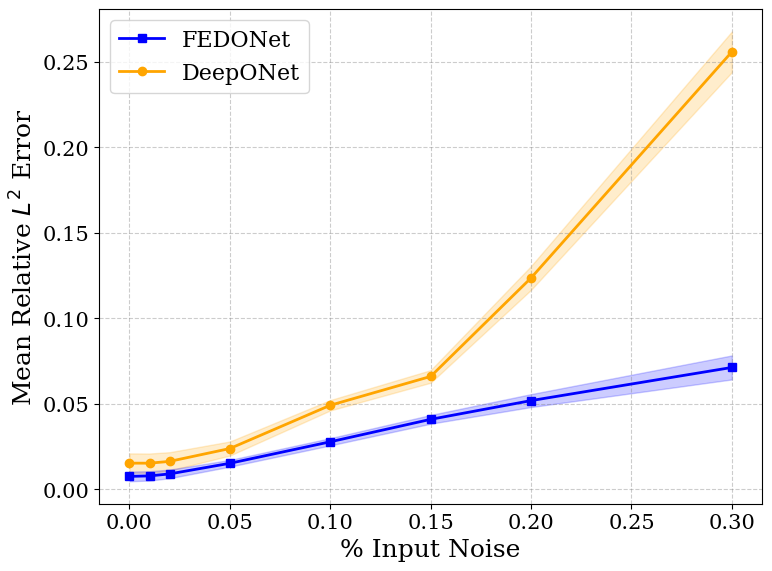

In [5]:
def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})

plt.figure(figsize=(8, 6))

plt.plot(
    noise_levels,
    fedonet_mean_errors,
    marker='s',
    color = 'blue',
    linewidth=2,
    label='FEDONet'
)

plt.plot(
    noise_levels,
    deeponet_mean_errors,
    marker='o',
    color = 'orange',
    linewidth=2,
    label='DeepONet'
)


plt.fill_between(
    noise_levels,
    np.array(deeponet_mean_errors) - np.array(deeponet_std_errors),
    np.array(deeponet_mean_errors) + np.array(deeponet_std_errors),
    color = 'orange',
    alpha=0.2
)

plt.fill_between(
    noise_levels,
    np.array(fedonet_mean_errors) - np.array(fedonet_std_errors),
    np.array(fedonet_mean_errors) + np.array(fedonet_std_errors),
    color = 'blue',
    alpha=0.2
)

plt.xlabel('% Input Noise')
plt.ylabel('Mean Relative $L^2$ Error')
# plt.title('Test Rel-L2 vs Fraction of Training Data', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

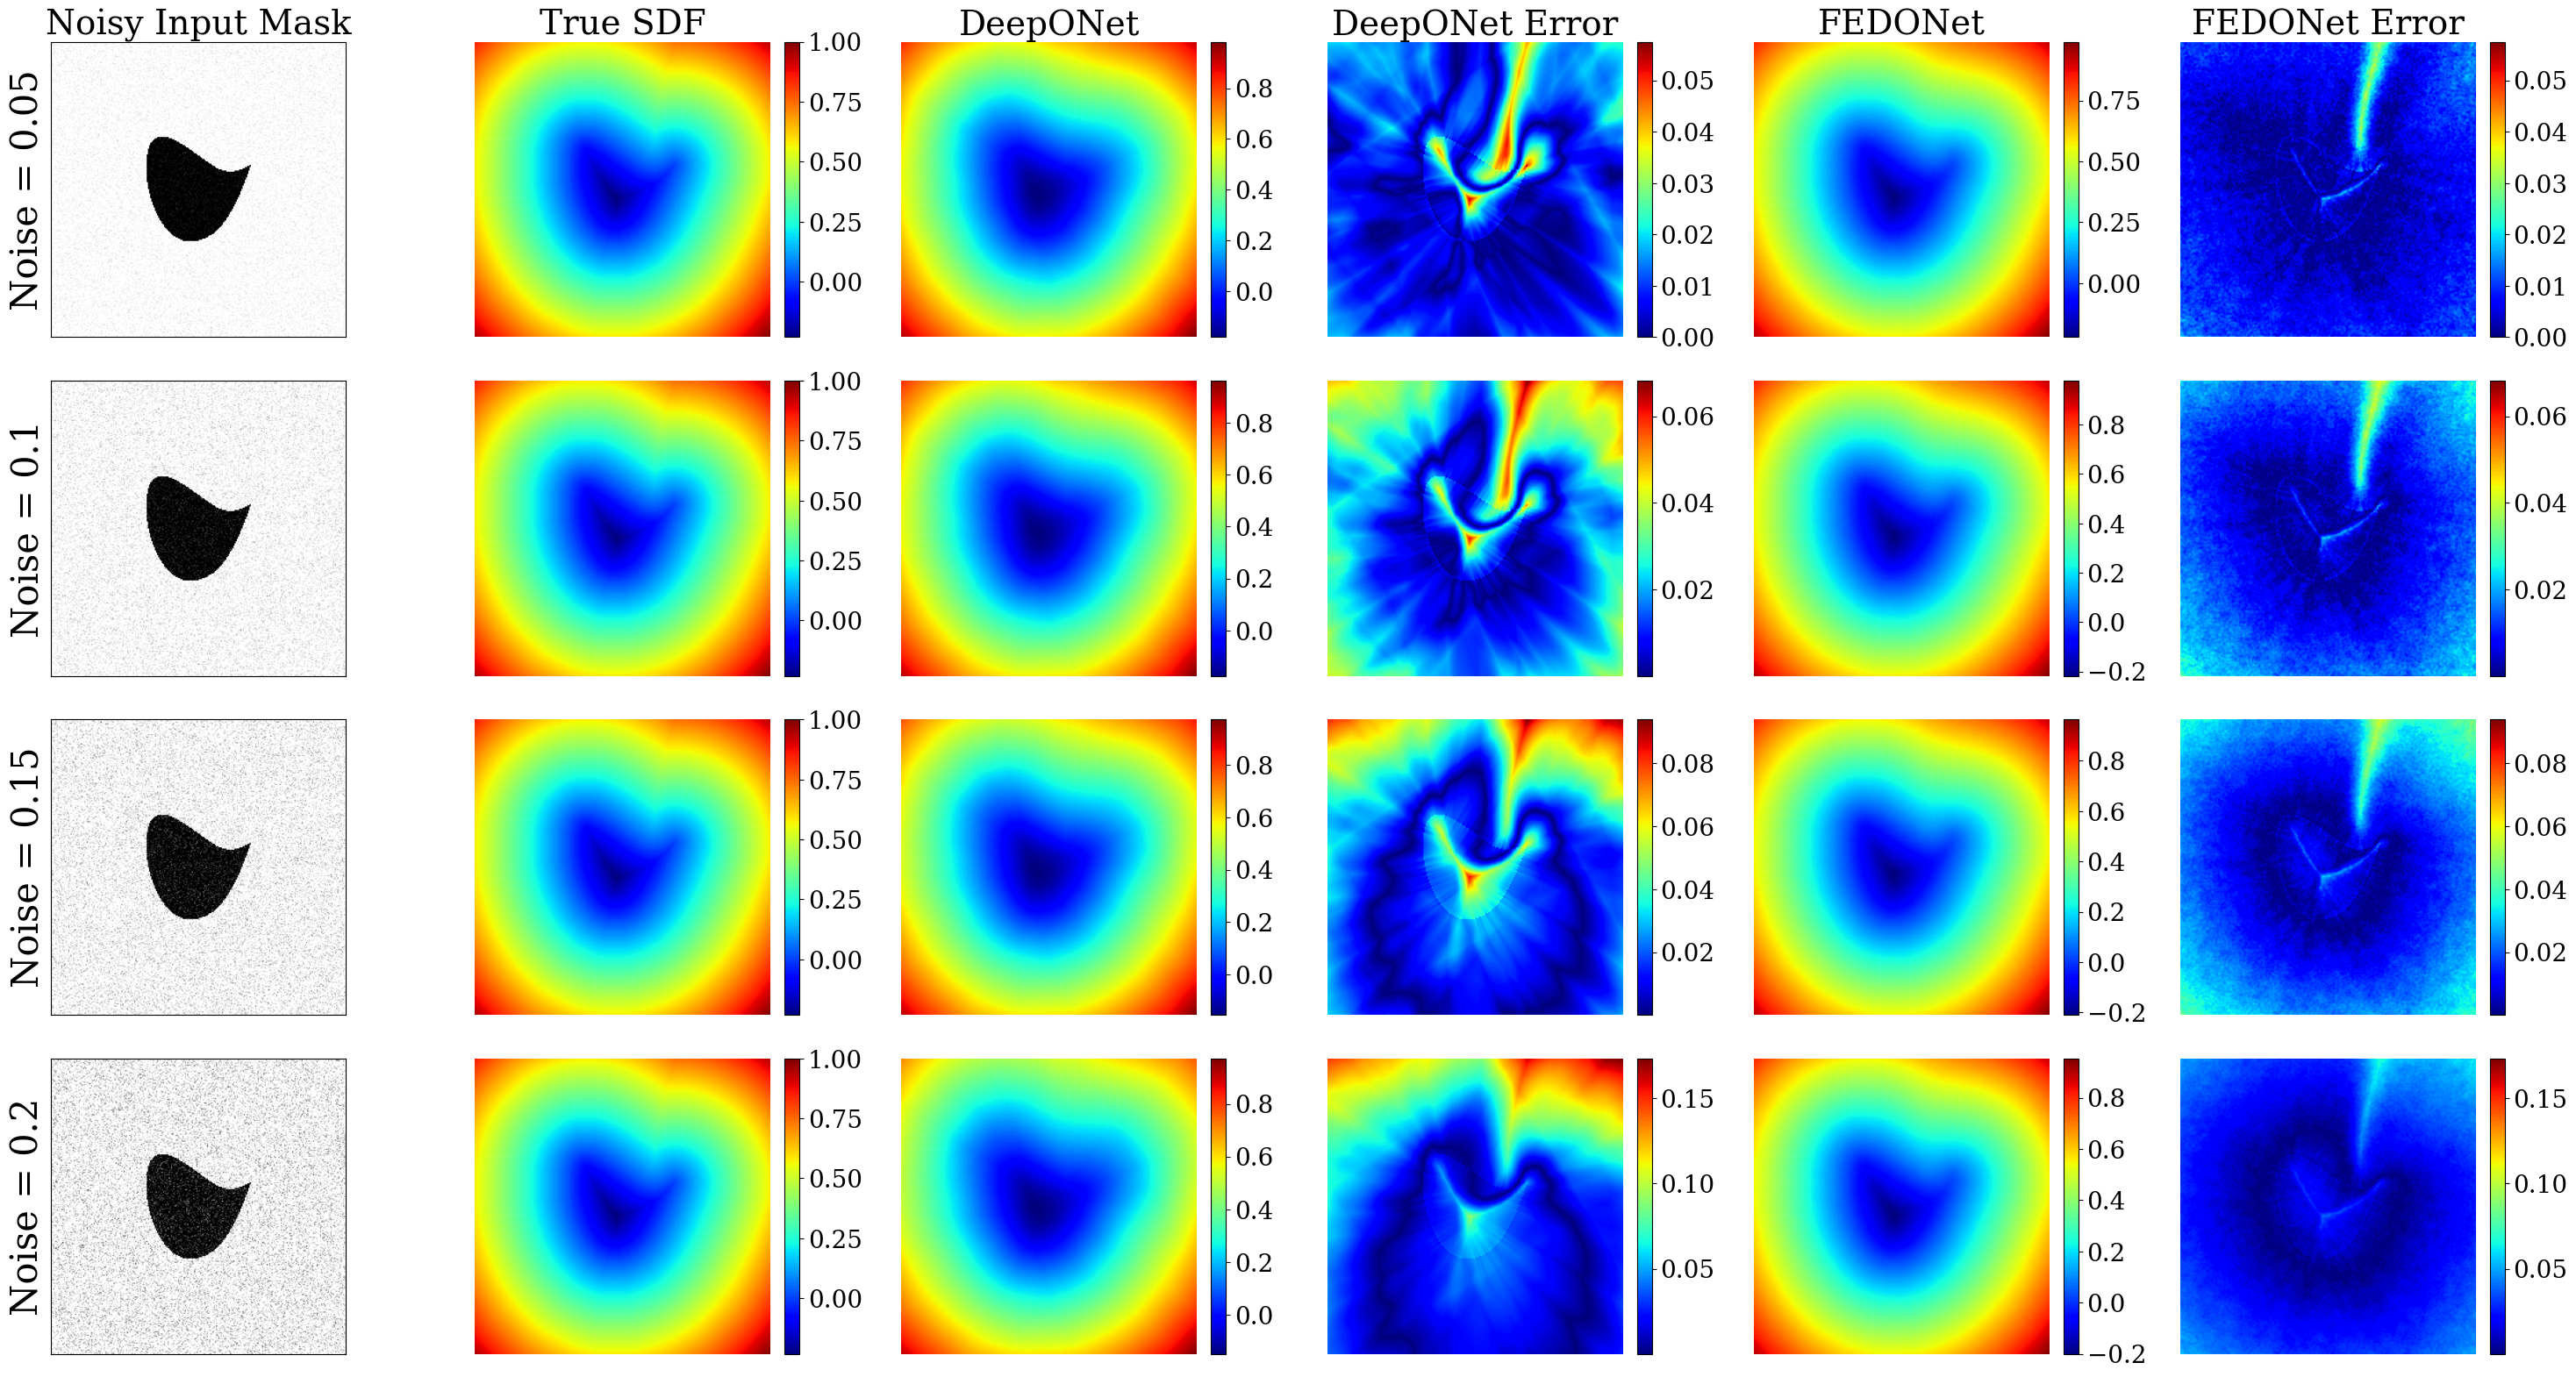

In [4]:
sample_idx = 0
mask_clean = mask_batch[sample_idx:sample_idx+1]
sdf_true = sdf_batch[sample_idx:sample_idx+1]

viz_noise_levels = [0.05, 0.1, 0.15, 0.2]

fig, axes = plt.subplots(len(viz_noise_levels), 6, figsize=(30, 4 * len(viz_noise_levels)))

if len(viz_noise_levels) == 1:
    axes = np.expand_dims(axes, axis=0)

deeponet.eval()
fedonet.eval()

def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22
})

with torch.no_grad():
    for row, nl in enumerate(viz_noise_levels):
        noisy_mask = add_gaussian_clipped_noise(mask_clean, nl)

        pred_deep = deeponet(noisy_mask, coords)
        pred_fedo = fedonet(noisy_mask, coords)

        noisy_mask_np = noisy_mask[0, 0].detach().cpu().numpy()
        sdf_true_np = sdf_true[0, 0].detach().cpu().numpy()
        pred_deep_np = pred_deep[0, 0].detach().cpu().numpy()
        pred_fedo_np = pred_fedo[0, 0].detach().cpu().numpy()

        err_deep = np.abs(sdf_true_np - pred_deep_np)
        err_fedo = np.abs(sdf_true_np - pred_fedo_np)

        e_deep = relative_l2_error_np(sdf_true_np, pred_deep_np)
        e_fedo = relative_l2_error_np(sdf_true_np, pred_fedo_np)
        
        # shared color scale for error plots
        err_min = min(err_deep.min(), err_fedo.min())
        err_max = max(err_deep.max(), err_fedo.max())

        ax = axes[row, 0]
        im = ax.imshow(noisy_mask_np, cmap='gray')
        if row==0:
            ax.set_title(f"Noisy Input Mask")
        ax.set_ylabel(f"Noise = {nl}", fontsize=30)    
        # remove ticks but keep labels
        ax.set_xticks([])
        ax.set_yticks([])

        ax = axes[row, 1]
        im = ax.imshow(sdf_true_np, cmap='jet')
        if row ==0:
            ax.set_title("True SDF")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[row, 2]
        im = ax.imshow(pred_deep_np, cmap='jet')
        if row ==0 :
            ax.set_title(f"DeepONet")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        ax = axes[row, 3]
        im = ax.imshow(err_deep, cmap='jet', vmin=err_min, vmax=err_max)
        if row==0:
            ax.set_title("DeepONet Error")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[row, 4]
        im = ax.imshow(pred_fedo_np, cmap='jet')
        if row==0:
            ax.set_title(f"FEDONet")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[row, 5]
        im = ax.imshow(err_fedo, cmap='jet', vmin=err_min, vmax=err_max)
        if row ==0:
            ax.set_title("FEDONet Error")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()